In [1]:
# IEEE project | Titanic Survival Prediction | Made by: Yashasvi Misra

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

train = pd.read_csv("train.csv")
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
test = pd.read_csv("test.csv")
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [4]:
train.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [5]:
test.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

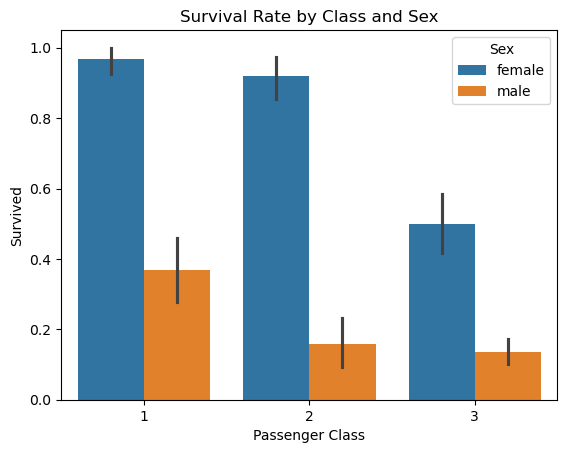

In [6]:
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=train)
plt.xlabel('Passenger Class')
plt.ylabel('Survived')
plt.title('Survival Rate by Class and Sex')
plt.show()
# This plot shows that female passengers had significantly higher rate of survival compared to male

In [7]:
# Fill missing age values with mean age
train['Age'] = train['Age'].fillna(train['Age'].mean())
test['Age'] = test['Age'].fillna(test['Age'].mean())
test['Fare'] = test['Fare'].fillna(test['Fare'].mean())

# Here, we assign male as 0 and female 1
train['Sex'] = train['Sex'].map({'male':0, 'female':1})
test['Sex'] = test['Sex'].map({'male':0, 'female':1})

# Fill the 2 missing embarked values with most frequent value(mode)
common_port = train['Embarked'].mode()[0]
train['Embarked'] = train['Embarked'].fillna(common_port)
test['Embarked'] = test['Embarked'].fillna(common_port)

# here we assign numerical values to embarked since our model cannot read S,C or Q
embarked_map = {'S':0, 'C':1, 'Q':2}
train['Embarked'] = train['Embarked'].map(embarked_map)
test['Embarked'] = test['Embarked'].map(embarked_map)
# here we drop these columns as they are not very useful for our model training.
train = train.drop(columns=['Cabin', 'Name', 'Ticket'])
test = test.drop(columns=['Cabin','Name','Ticket'])

In [8]:
# here we choose those features we want the model to analyse
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare','Embarked']
X = train[features]
y = train['Survived'] #this is what we want to predict
#we use 20% of data for testing model accuracy
X_train, X_val, y_train, y_val = train_test_split(X,y,test_size=0.2, random_state=42)

# Normalize features to ensure all data points are treated with equal weight by the model
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

predictions = model.predict(X_val)
accuracy = accuracy_score(y_val, predictions)
print(f"Validation accuracy: {accuracy*100:0.2f}%")

Validation accuracy: 79.89%


In [9]:
X_test = test[features]
X_test_scaled = scaler.transform(X_test)

predictions = model.predict(X_test_scaled)
submission = pd.DataFrame({
    'PassengerId':pd.read_csv('test.csv')['PassengerId'],
    'Survived':predictions
})

submission.to_csv('submission.csv', index=False)